In [2]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import joblib
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 2. Load Dataset
data = fetch_california_housing()
X = data.data
y = data.target

# Create DataFrame
df = pd.DataFrame(X, columns=data.feature_names)
df['PRICE'] = y

In [4]:
# 3. Explore the Data
print("Head of Dataset:\n", df.head())
print("\nInfo:\n")
print(df.info())
print("\nSummary:\n", df.describe())

Head of Dataset:
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  PRICE  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null

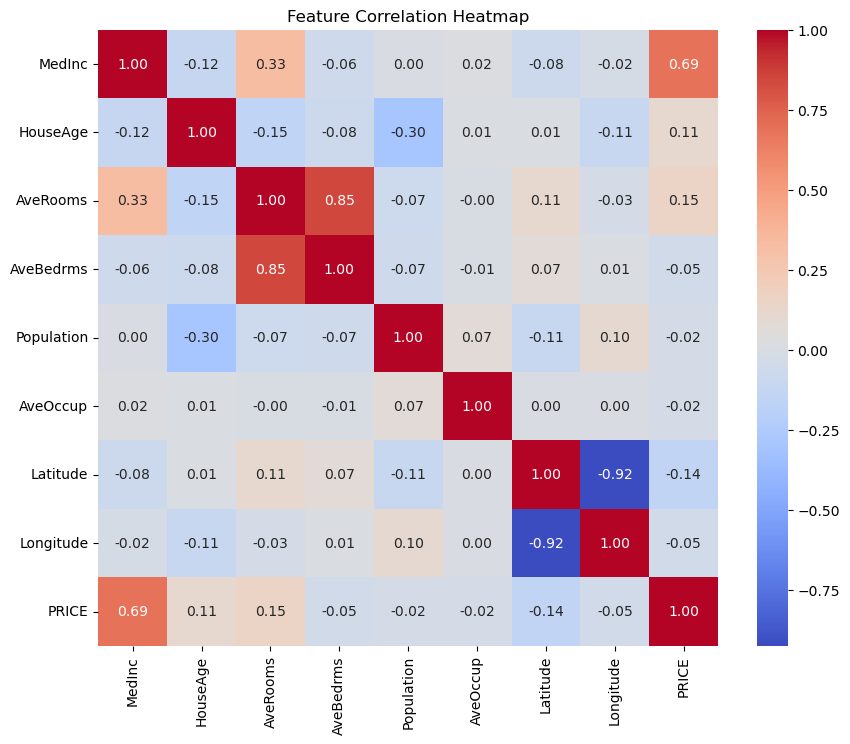

In [5]:
# 4. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

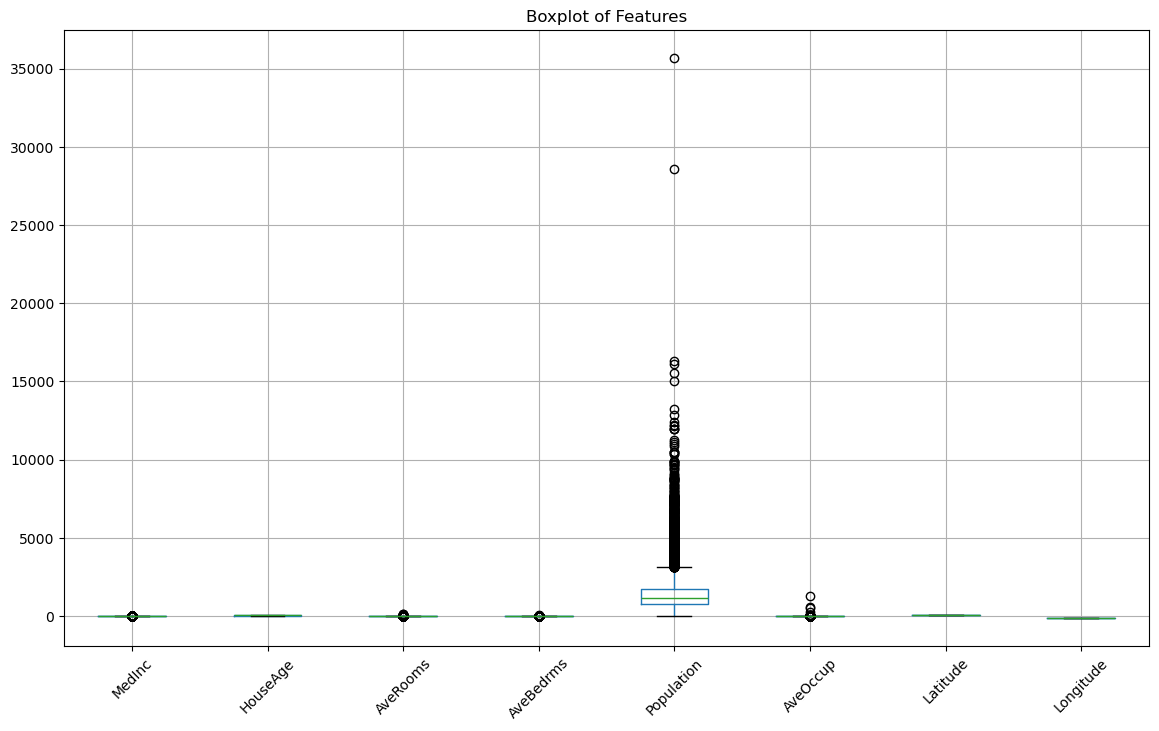

In [6]:
# 4.1 Boxplot of Features (excluding target)
plt.figure(figsize=(14, 8))
df.drop("PRICE", axis=1).boxplot()
plt.title("Boxplot of Features")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

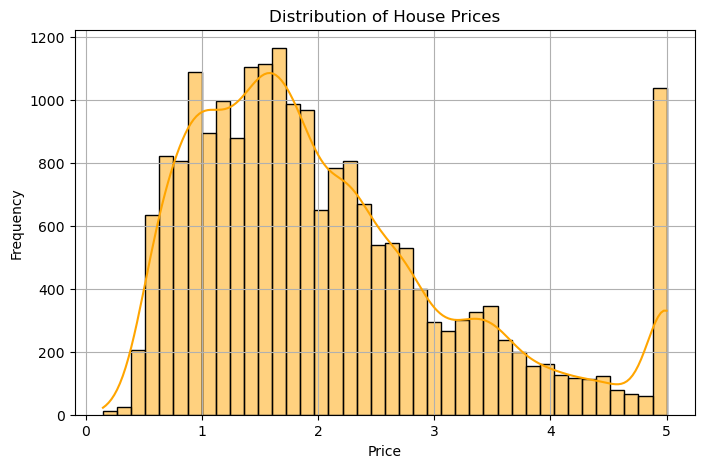

In [7]:
# 4.2 Distribution of Target (PRICE)
plt.figure(figsize=(8, 5))
sns.histplot(df['PRICE'], bins=40, kde=True, color='orange')
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

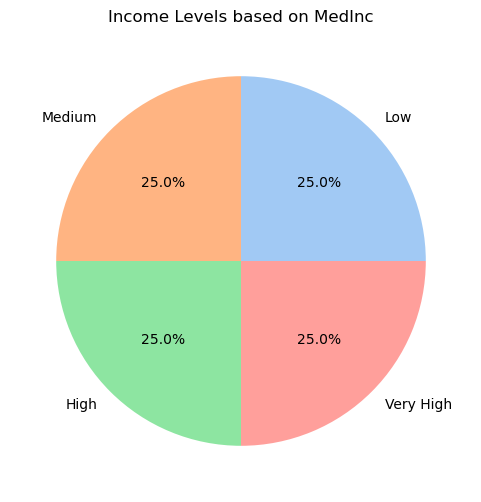

In [8]:
# 4.3 Income Level Pie Chart
df['Income_Level'] = pd.qcut(df['MedInc'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
income_counts = df['Income_Level'].value_counts()

plt.figure(figsize=(6, 6))
colors = sns.color_palette('pastel')
plt.pie(income_counts, labels=income_counts.index, autopct='%1.1f%%', colors=colors)
plt.title("Income Levels based on MedInc")
plt.show()

In [9]:
# 5. Prepare Data
X = df.drop(['PRICE', 'Income_Level'], axis=1)
y = df['PRICE']

In [11]:
# 6. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Train Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 8. Make Predictions
y_pred = rf_model.predict(X_test)

In [12]:
# 9. Evaluate Model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nRandom Forest Performance:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")


Random Forest Performance:
Mean Squared Error (MSE): 0.26
R² Score: 0.81


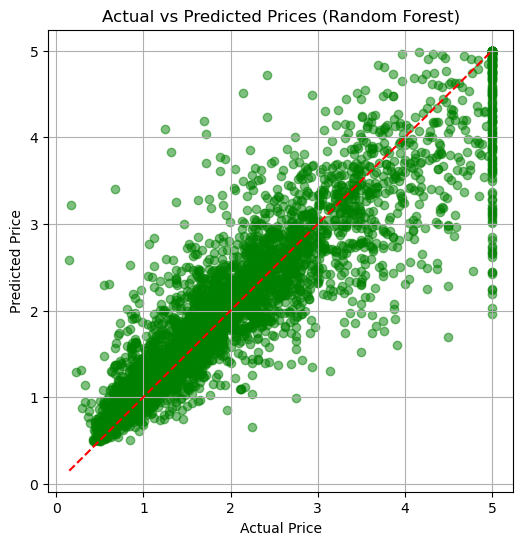

In [13]:
# 10. Actual vs Predicted Plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='green', alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (Random Forest)")
plt.grid(True)
plt.show()